# Practical session 4 - K-nearest neighbours (K-NN) classification with numpy, scikit-learn, cython and numba

Students (pair):
- [Loïc Soulet]([link](https://github.com/lsol1))
- [Marceau Bouilly]([link](https://github.com/marcaIL))

**Useful references for this lab**:

[1] scikit-learn: [documentation](https://scikit-learn.org/stable/modules/neighbors.html?highlight=knn%20classification)

[2] `numba`: [documentation](http://numba.pydata.org/) 

[3] cython: [a very useful tutorial](https://cython.readthedocs.io/en/latest/src/userguide/numpy_tutorial.html#numpy-tutorial), and [another one](http://docs.cython.org/en/latest/src/tutorial/cython_tutorial.html)



## <a name="content">Contents</a>
- [Exercise 1: KNN classification with numpy and sklearn](#ex1)
- [Exercise 2: Code acceleration with cython](#ex2)
- [Exercise 3: Code acceleration with numba](#ex3)
---

In [1]:
import numpy as np
import numba
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
import timeit
from sklearn.model_selection import train_test_split
import unittest

## <a name="ex1">Exercise 1: K-Nearest Neighbours (K-NN) classification with numpy and scikit-learn</a> [(&#8593;)](#content)

This session is a first introduction to classification using the most intuitive non parametric method: the $K$-nearest neighbours. The principle is [the following](https://scikit-learn.org/stable/modules/neighbors.html?highlight=knn%20classification). A set of labelled observations is given as a learning set. A classification taks then consists in assigning a label to any new observation. In particular, the K-NN approach consists in assigning to the observation the most frequent label among its $K$ nearest neighbours taken in the training set.

### A. Validation on synthetic data

Load the training and test datasets `data/synth_train.txt` and `data/synth_test.txt`. Targets belong to the set $\{1,2\}$ and entries belong to $\mathbb{R}^2$. The file `data/synth_train.txt` contain 100 training data samples, and `data/synth_test.txt` contains 200 test samples, where:

- the 1st column contains the label of the class the sample;
- columns 2 & 3 contain the coordinates of each sample (in $\mathbb{R}^2$).

Useful commands can be found below.

```python
# load the training set
train = np.loadtxt('data/synth_train.txt')  #...,delimiter=',') if there are ',' as delimiters
class_train = train[:,0]
x_train = train[:,1:]
N_train = train.shape[0]
```

```python
# load the test set
test = np.loadtxt('/datasynth_test.txt') 
class_test_1 = test[test[:,0]==1]
class_test_2 = test[test[:,0]==2]
x_test = test[:,1:]
N_test = test.shape[0]
```

1\. Display the training set and distinguish the two classes. 

> Hint: useful functions include `matplotlib.pyplot.scatter` or `matplotlib.pyplot.plot`.

**Answer:**

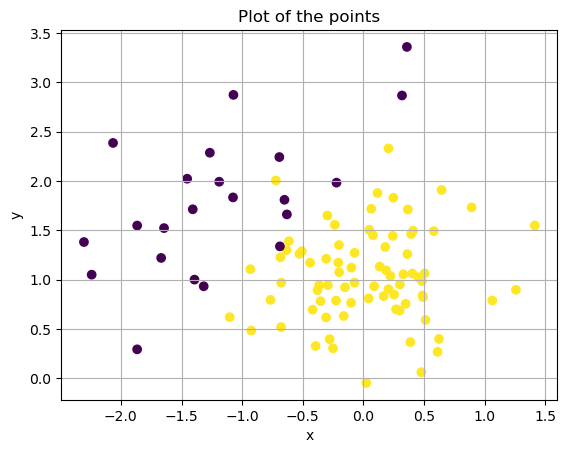

In [2]:
# load the training set
train = np.loadtxt('./data/synth_train.txt')  #...,delimiter=',') if there are ',' as delimiters
class_train = train[:,0]
class_train = class_train.astype(int)
x_train = train[:,1:]
N_train = train.shape[0]

# load the test set
test = np.loadtxt('./data/synth_test.txt')
class_test = test[:,0]
class_test = class_test.astype(int)
x_test = test[:,1:]
N_test = test.shape[0]

#plot the training set
plt.scatter(x_train[:,0], x_train[:,1], c = class_train)
plt.grid()
plt.title("Plot of the points")
plt.xlabel('x')
plt.ylabel('y')
plt.savefig('images/plot_training_set.png')
plt.show()


2\. Implement the K-nearest neighbours algorithm for classification.

> Hint: 
> - useful functions include `numpy.linalg.norm`, `numpy.argsort`, `numpy.bincount`;
> - implement the algorithm as a function rather than an object. This will drastically simplify the acceleration step using Cython.
> - for an optimized partial sorting procedure, you may have a look at the [`bottleneck.argpartition` function](https://bottleneck.readthedocs.io/en/latest/reference.html#bottleneck.argpartition).
> 1. Compute for each row in `x_test` (if necessary use `np.newaxis`) its distance with respect to `x_train`:
>  - Use  `numpy.linalg.norm` (in which dimension this distance is computed ? Consider using `axis` argument)
> 2. Sort the ordered collection of distances (indices from smallest to largest (in ascending order) by the distances):
>   - Use `np.argsort` (at the end replace this procedure by `bottleneck.argpartition`)
>   - Once the sorting is done, we take only the indices of `labels` of the `n_neighbours` nearest neighbours of the `class_train` :
>     - `id = np.argsort(distances)[:n_ neighbours]` and `labels = class_train[id]`
> 3. The K-nearest can be used for **Regression**, in this case it is necessary to return the mean of the K-labels. For **Classification**,  we return the mode of the K-labels :
> - Use `np.bincount` for `labels` to affect the variable `class_pred[q]` (for row `q`). This procedure counts the number of occurrences of each value in array. **Mode** is the value that appears. How can we get this value ?


```python
import numpy as np
import bottleneck as bn

# Create a random array
arr = np.random.rand(10)
N = 3  # Number of smallest elements to retrieve

# Using np.argsort() to get indices of the first N elements
sorted_indices = np.argsort(arr)[:N]

# Using bottleneck.argpartition() to get the first N smallest indices
partitioned_indices = bn.argpartition(arr, N)[:N]

# Display the results
print("Original array:", arr)
print("Indices using np.argsort:", sorted_indices)
print("First N elements using np.argsort:", arr[sorted_indices])

print("Indices using bottleneck.argpartition:", partitioned_indices)
print("First N elements using bottleneck.argpartition:", arr[partitioned_indices])

are_equal = set(arr[sorted_indices]) == set(arr[partitioned_indices])
print(are_equal)
```


**Answer:**

In [3]:
#See functions/exercice1 for KNN implementation
from functions.exercise1 import KNN
import unittests.test_knn as test_knn

#unit test on our implementation
loader = unittest.TestLoader()
suite = loader.loadTestsFromModule(test_knn)
runner = unittest.TextTestRunner(verbosity=2)
runner.run(suite)

test_multiple_points (unittests.test_knn.TestKNN.test_multiple_points) ... ok
test_single_point_k1 (unittests.test_knn.TestKNN.test_single_point_k1) ... ok
test_single_point_k3 (unittests.test_knn.TestKNN.test_single_point_k3) ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.019s

OK


<unittest.runner.TextTestResult run=3 errors=0 failures=0>

In [4]:
#Predict class on our dataset
class_pred = KNN(x_train, class_train ,x_test, N_test, K = 10)

#
labels, counts  =np.unique(class_pred, return_counts = True)
print(f"label {labels[0]} : {counts[0]} points")
print(f"label {labels[1]} : {counts[1]} points")

label 1 : 47 points
label 2 : 153 points


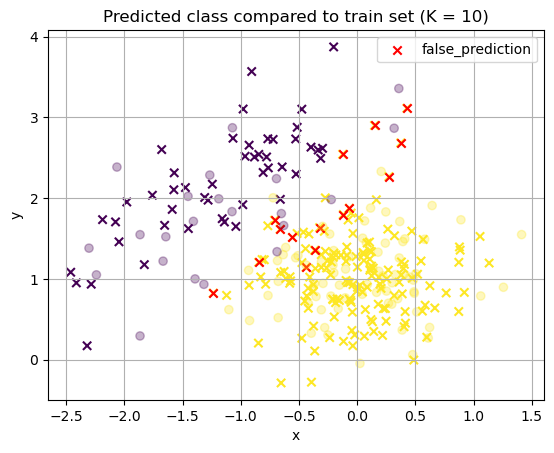

In [5]:
#Plot the test set with predicted classes compared to the training set
from functions.exercise1 import predict_and_plot
predict_and_plot(x_train, class_train, x_test, class_test, N_test, 10)

3\. Compute the error rate on the training set and the test set for $K \in \{1,2, \dotsc, 20\}$. Display the classification result (see 1.) for the configuration with the lowest error rate.

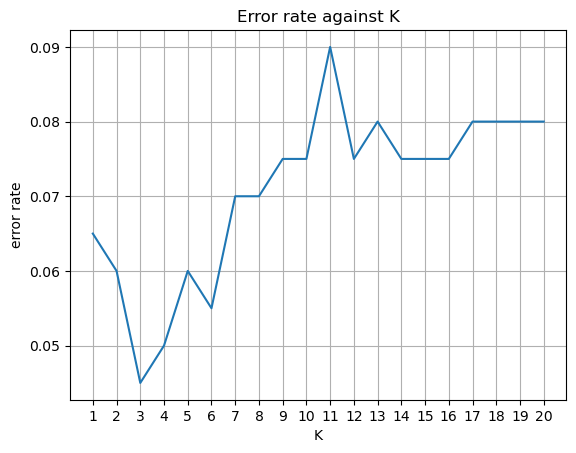

In [6]:
#See functions/exercise1 to see the error rate function definition
from functions.exercise1 import get_error_rate

#Predict class and compute the error rate for K in [1,20]

K_list = list(range(1,21))
error_rate = []
for K in K_list:
    class_pred_K = KNN(x_train, class_train, x_test, N_test, K)
    error_rate_K = get_error_rate(class_pred_K, class_test)
    error_rate.append(error_rate_K)
error_rate = np.array(error_rate)

#Plot the error rate vs K
plt.grid()
plt.xticks(K_list)
plt.plot(K_list, error_rate)
plt.xlabel("K")
plt.ylabel("error rate")
plt.title("Error rate against K")
plt.savefig('images/error_against_K_synthetic_data.png')
plt.show()

**Answer:**

4\. Comment on your results. Which value of $K$ seems optimal ?


**Comment** 
- We can see the importance of choosing the optimal K value, with a high difference between prediction results with or without optimal K (can double the error in our case). 
- Furthermore, we can see that using a KNN classification method on this dateset is pretty efficient, with an error under 5% for the optimal K. 

**Answer:**

In [7]:
#Print optimal K and lowest error
optimal_K = np.argmin(error_rate) + 1
print(f'Optimal K : {optimal_K}')
print(f'Error rate for optimal K : {np.min(error_rate)}')

Optimal K : 3
Error rate for optimal K : 0.045


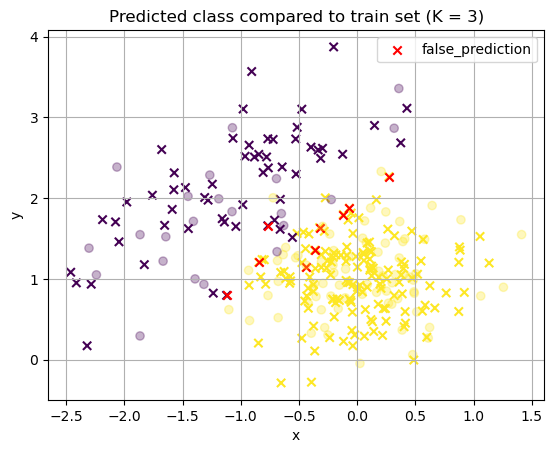

In [8]:
predict_and_plot(x_train, class_train, x_test, class_test, N_test, optimal_K)

5\. Compare the results of you implementation with those of [`sklearn.neighbors.KNeighborsClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html?highlight=kneighborsclassifier#sklearn.neighbors.KNeighborsClassifier). Compare the runtime of these two versions using the [`timeit`](https://docs.python.org/3/library/timeit.html) module (see session 1).

**Answer:**

In [9]:
# instantiate and use KNN_classifier from sklearn
KNN_classifier = KNeighborsClassifier(n_neighbors=3)
KNN_classifier.fit(x_train, class_train)

class_pred_sklearn = KNN_classifier.predict(x_test)

class_pred_homemade = KNN(x_train, class_train, x_test, N_test, 3)

print(f"error sklearn model: {get_error_rate(class_pred_sklearn, class_test)}")
print(f"error homemade model: {get_error_rate(class_pred_homemade, class_test)}")


error sklearn model: 0.045
error homemade model: 0.045


**Remark :** 

The error rate of our implemented model matches that of the scikit-learn model, providing additional validation for our implementation.

In [10]:
#define function without arguments
def KNN_homemade_timeit():
    return KNN(x_train, class_train, x_test, N_test, 3)

def KNN_sklearn_timeit():
    KNN_classifier = KNeighborsClassifier(n_neighbors=3)
    KNN_classifier.fit(x_train, class_train)
    class_pred_sklearn = KNN_classifier.predict(x_test)
    return class_pred_sklearn

#runtime comparison
exec_time_homemade = timeit.timeit(KNN_homemade_timeit, number = 1000)
exec_time_sklearn = timeit.timeit(KNN_sklearn_timeit, number = 1000)

print(f"execution time of our homemade KNN function : {np.round(exec_time_homemade, 3)}")
print(f"execution time of sklearn KNN function : {np.round(exec_time_sklearn, 3)}")

execution time of our homemade KNN function : 12.785
execution time of sklearn KNN function : 2.727


**Comment** :

 We can see that our KNN classifier is more than 2 time slower than the sklearn model. The fact that our model is coded in python make it necessarly slower than the sklearn model, which is coded in C. 

### B. Application to a real dataset (Breast cancer Wisconsin).

6\. Apply the K-NN classifier to the real dataset `data/wdbc12.data.txt.` Further details about the data are provided in `data/wdbc12.names.txt`.

> Hint: you can use the function [`train_test_split` from `sklearn.model_selection`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) to split the dataset into a training and a test set.

**Answer:**

In [11]:
# Import data
data = np.loadtxt('data/wdbc12.data.txt', delimiter=',')
data_train, data_test = train_test_split(data, test_size=0.2, random_state=42)

y_train = data_train[:, 1]
X_train = data_train[:, 2:]

y_test = data_test[:, 1]
X_test = data_test[:, 2:]

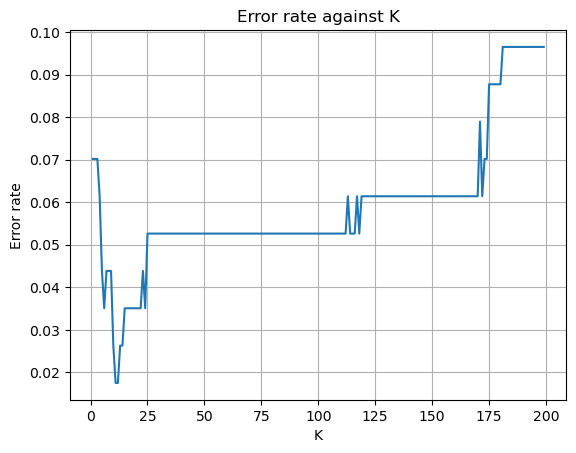

In [12]:
#Find optimal K for sklearn KNN Classifier
K_list = list(range(1, 200))
error_rate_wdbc_K = []

for K in K_list :
    wdbc_knn = KNeighborsClassifier(n_neighbors = K)
    wdbc_knn.fit(X_train, y_train)
    y_hat = wdbc_knn.predict(X_test)
    error_rate_wdbc_K.append(get_error_rate(y_hat, y_test))

#Plot error rate against K
plt.plot(K_list, error_rate_wdbc_K)
plt.title("Error rate against K")
plt.xlabel('K')
plt.ylabel('Error rate')
plt.grid()
plt.savefig('images/error_against_K_real_data.png')
plt.show()

In [13]:
#Predict with optimal K
optimal_K_wdbc = np.argmin(error_rate_wdbc_K) + 1
print(f"Optimal K : {optimal_K_wdbc}")

optimal_knn_wdbc = KNeighborsClassifier(optimal_K_wdbc)
optimal_knn_wdbc.fit(X_train, y_train)
y_final = optimal_knn_wdbc.predict(X_test)
print(f'lowest error rate : {np.min(error_rate_wdbc_K)}')

Optimal K : 11
lowest error rate : 0.017543859649122806


**Remark :**

The error rate is minimal for K = 11, reaching a good result with less than 2% of error. 

Since we cannot visualize our predictions due to the high dimensionality (n=30), we projected the test set into 2D using [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) and plotted the predicted classes.

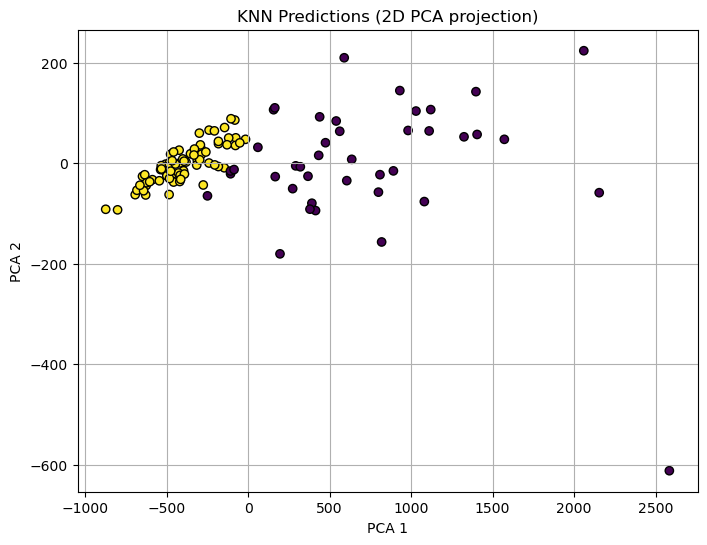

In [14]:
from sklearn.decomposition import PCA
# Reduce to 2D with PCA
pca = PCA(n_components=2)
X_test_2D = pca.fit_transform(X_test)

# --- Plot predictions ---
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_test_2D[:,0], X_test_2D[:,1], c=y_final, cmap="viridis", edgecolor="k")
plt.title("KNN Predictions (2D PCA projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid()
plt.savefig('images/prediction_pca_visualization.png')
plt.show()


## <a name="ex2">Exercise 2: Code acceleration with cython</a> [(&#8593;)](#content)

Cython allows C code to be easily interfaced with Python. It can be useful to make your code faster for a small coding effort, in particular when using loops. A general approach to optimize your code is outlined in the [Scipy lecture notes, Section 2.4](https://scipy-lectures.org/advanced/optimizing/index.html). Complementary reading about interfacing Python with C can be found in [Section 2.8](https://scipy-lectures.org/advanced/interfacing_with_c/interfacing_with_c.html).

1\. Read carefully the [cython tutorial](http://docs.cython.org/en/latest/src/tutorial/cython_tutorial.html), which describes step by the step how the toy example reported below has been developed.

**Setup**: Compile the toy example provided in `example_cy/` by running, in the command line (anaconda prompt on windows)

```bash
cd example_cy && python setup.py build_ext --inplace
```

Note that the compilation process has been slightly automatised with the instructions reported in `example_cy/setup.py`. To test the module, run

In [15]:
!cd example_cy && python setup.py build_ext --inplace

In [16]:
from example_cy import helloworld as toy

toy.printhello()

Hello World


which should display
```python
Hello World
```

> Warning: 
> - do not forget to include an empty `__init__.py` file in the directory where your source code lives (`import` will fail if this is not the case).
> - in case you have any setup issue, take a look at the `notes.md` file.
> - if the C code and/or the executable do not seem to be regenerated by the build instructions, delete the C code and the executable first, and re-execute the compilation afterwards.
> - do not hesitate to restart the Python kernel if necessary when the Cython executable has been re-generated.

2\. Read the [Numpy/Cython tutorial](https://cython.readthedocs.io/en/latest/src/userguide/numpy_tutorial.html#numpy-tutorial), focussing on the paragraphs **Cython at a glance**, and **Your Cython environment** until **"More generic code"**. An example to compile a `.pyx` file depending on `numpy` is included in `example_np_cy/`.

> Remarks: 
> - the `annotate=True` flag in the `setup.py` allows an additional `.html` document to be generated (`<your_module_name>.html`), showing, for each line of the Cython code, the associated C instructions generated. Highlighted in yellow are the interactions with Python: the darker a region appears, the less efficient the generated C code is for this section. Work in priority on these! 
> - make sure all the previously generated files are deleted to allow the .html report to be generated;
> - if you are working on your own machine and don't have a C/C++ compiler installed, read the notes provided in `notes.md`;
> - use `cdef` for pure C functions (not exported to Python), `cpdef` should be favored for functions containing C instructions and later called from Python.

**Answer:**

In [17]:
# your code
!cd example_np_cy && python setup.py build_ext --inplace

3\. Use Cython to implement a faster version of the numpy K-NN classifier implemented in [Exercise 1](#ex1). To do so, apply step-by-step the techniques introduced in the [Numpy/Cython tutorial](https://cython.readthedocs.io/en/latest/src/userguide/numpy_tutorial.html#numpy-tutorial) (*i.e.*, compile and time your code after each step to report the evolution, keeping track of the different versions of the cython function).

> Hint: if you keep numpy arrays, make sure you use memory views (see numpy/cython tutorial) to access the elements within it. Be extremely careful with the type of the input arrays (you may need to recast the format of the input elements before entering the function. The `numpy.asarray` function can prove useful).

> **Detailed guidelines**: a few notes and *caveat* to help you re-writing your code in cython:
> - try to reduce the number of calls to numpy instructions as much as possible;
> - **you do not have to optimize everything**. For the KNN function above, most of the time is spent in computing euclidean distances: you can thus focus on optimizing tihs operations by explicitly writing a for loop, which will ensure a minimal interaction with numpy when generating the associated C code at compilation. Calls to other numpy functions can be kept as-is;
> - if you need to create an array within the cython function, used np.zeros (**do NOT use python lists**), and use a memory view to access its content;
> - specify the type for all variables and numpy arrays. Pay attention to the type of the input arrays passed to the Cython function;
> - whenever an array is returned, use memory views and index(es) to efficiently access its content;
> - some numpy operators (e.g., broadcasting mechanism) do not work with memory views. In this case, you can directly write for loop(s) to encode the operation of interest (the loops will be optimized out at compile time);
> - only use at the final development stage the following cython optimization (not before, as they can crash the program without any help):
>
>```python
>@cython.boundscheck(False)
>@cython.wraparound(False)
>```

**Answer:**

In [ ]:
# your code
!cd knn_cy && python setup.py build_ext --inplace

4\. Compare the runtime of the two algorithms (using `timeit.timeit`), and conclude about the interest of using cython in this case.

**Answer:**

**We made two major modifications to optimize our code with Cython:**
- **Computing distances using nested loops**
- **Adding typed memoryviews**

**The function ```knn_optimized_v1``` implements only the first modification, while ```knn_optimized_v2``` incorporates both.**

In [ ]:
# Check knn_cy/knn.pyx for the implementation
from knn_cy.knn import knn_optimized_v1, knn_optimized_v2
N_test = X_test.shape[0]
y_train = y_train.astype(int)

class_pred_optimized = knn_optimized_v1(X_train, y_train, X_test, N_test, optimal_K_wdbc)
class_pred_optimized2 = knn_optimized_v2(X_train, y_train, X_test, N_test, optimal_K_wdbc)


print(get_error_rate(class_pred_optimized, y_test))
print(get_error_rate(class_pred_optimized2, y_test))

0.017543859649122806
0.017543859649122806


**Remark : The error rate for both functions matches the one reached by sklearn model (see ex2), our optimization does not compromise the quality of the result.**

In [ ]:
def KNN_optimized_timeit_wbdc():
    return knn_optimized_v1(X_train, y_train, X_test, N_test, optimal_K_wdbc)

def KNN_optimized2_timeit_wbdc():
    return knn_optimized_v2(X_train, y_train, X_test, N_test, optimal_K_wdbc)

def KNN_homemade_timeit_wbdc():
    return KNN(X_train, y_train, X_test, N_test, optimal_K_wdbc)

def KNN_sklearn_timeit_wbdc():
    KNN_classifier = KNeighborsClassifier(n_neighbors=optimal_K_wdbc)
    KNN_classifier.fit(X_train, y_train)
    class_pred_sklearn = KNN_classifier.predict(X_test)
    return class_pred_sklearn

exec_time_optimized = timeit.timeit(KNN_optimized_timeit_wbdc, number = 1000)
exec_time_optimized2 = timeit.timeit(KNN_optimized2_timeit_wbdc, number = 1000)
exec_time_homemade = timeit.timeit(KNN_homemade_timeit_wbdc, number = 1000)
exec_time_sklearn = timeit.timeit(KNN_sklearn_timeit_wbdc, number = 1000)

print(f"execution time of our homemade KNN function : {np.round(exec_time_homemade, 3)} seconds")

print(f"execution time of sklearn KNN function : {np.round(exec_time_sklearn, 3)} seconds")

print(f"execution time of our v1 optimized KNN function : {np.round(exec_time_optimized, 3)} seconds")

print(f"execution time of our v2 optimized KNN function : {np.round(exec_time_optimized2, 3)} seconds")

execution time of our homemade KNN function : 8.56 seconds
execution time of sklearn KNN function : 2.695 seconds
execution time of our v1 optimized KNN function : 2.868 seconds
execution time of our v2 optimized KNN function : 2.624 seconds


**Our homemade KNN function is significantly slower (8.56 s) compared to scikit-learn’s implementation (2.695 s), likely due to pure Python overhead in distance computations. The first optimized version (v1) reduces the time to 2.868 s by manually computing distances in nested loops using Cython, which eliminates some Python overhead. The second optimized version (v2), which also uses typed memoryviews, further improves performance to 2.624 s, making it slightly faster than v1 and approaching scikit-learn’s efficiency.**

## <a name="ex3">Exercise 3: Code acceleration with numba</a> [(&#8593;)](#content)

`numba` is a just-in-time (JIT) compiler which translates Python codes into efficient machine code at runtime. A significant acceleration can be obtained by adding a few simple decorators to a standard Python function, up to a few restrictions detailed [here](http://numba.pydata.org/numba-doc/latest/user/performance-tips.html).

If you have written most of the KNN classifier of exercise 1 with numpy, there is little to no chance that you will get an acceleration with numba (justifying the use of cython in this case). An interesting acceleration factor can however be obtained for the computation of the total variation investigated in session 2.

1\. Take a look at the [numba 5 min tour](http://numba.pydata.org/numba-doc/latest/user/5minguide.html), and accelerate the total variation code from session 2 with the `@jit` decorator. You may have to rewrite small portions of your code to get the expected acceleration (see [performance tips](http://numba.pydata.org/numba-doc/latest/user/performance-tips.html)).

**Answer:**

**We first import the functions from the lab 2, and we develop a module with two different optimised functions using numba**

In [ ]:
# your code
from functions.exercise3 import TV
from functions.exercise3_optimised import TV_optimised, TV_compact

**This module contains the code of two different accelerated versions of the TV :**

- **The $\text{TV-optimised}$ function aims to keep the functions structure of the original TV function. We just splited the operations to parallelize the loop, use fastmath annotation, and exploit the nopython mode optimisation of numba. (trying to avoid numpy vectorized functions)**

- **The $\text{TV-compact}$ function aims to reduce at most the number of calculation, loops and memory allocation. It reduces the verbosity of the function to a few lines. This function should not be optimised with a classic python implementation, but as numba is strong at parallelize loops, we will obtain good performances.**

**We first run a test to ensure the results produced by our functions**

In [ ]:
# your code
class TestTV(unittest.TestCase):
    def test_tv_constant(self):
        #With a constant columns among the matrix, the TV is supposed to be zero
        X = np.zeros((3, 3))
        result=TV(X)
        np.testing.assert_allclose(result,0,atol=1e-6,rtol=1e-8)

    def test_tv_known(self):
      #We did the calculation by hand to know the result to expect
        X = np.array([[0, 0, 0],
                      [0, 1, 0],
                      [0, 0, 0]], dtype=float)
        result=TV(X)
        result_opt=TV_optimised(X)
        result_compact=TV_compact(X)
        np.testing.assert_allclose(result,3.41,atol=1e-2)
        np.testing.assert_allclose(result_opt,3.41,atol=1e-2)
        np.testing.assert_allclose(result_compact,3.41,atol=1e-2)

unittest.main(argv=[''], verbosity=2, exit=False)

test_tv_constant (__main__.TestTV.test_tv_constant) ... ok


test_tv_known (__main__.TestTV.test_tv_known) ... ok

----------------------------------------------------------------------
Ran 2 tests in 4.780s

OK


2\. Compare the runtime of the your numpy implementation and the `numba`-accelerated version (using `timeit.timeit`). 
> **Warning**: first run the numba version once to trigger the compilation, and then time it as usual. This is needed to avoid including the JIT compilation step in the runtime.

**Answer:**

In [ ]:
from functions.exercise3 import generate_random_matrix_m_n

#Matrix for perf test
A=generate_random_matrix_m_n(10,10)
print(TV_optimised(A))

43.284629999157794


In [ ]:
f = lambda : TV(A)
f_optimised = lambda : TV_optimised(A)
f_compact = lambda : TV_compact(A)

We make the first call to the functions to avoid including JIT compilation

In [ ]:
K = TV_optimised(A)
K2=TV_compact(A)

In [ ]:
#We now use timeit to compare the runtimes of the functions
exec_time_f=timeit.timeit(f,number=1000)
exec_time_f_optimised=timeit.timeit(f_optimised,number=1000)
exec_time_f_numba=timeit.timeit(f_compact,number=1000)


print(f"execution time for function TV : {np.round(exec_time_f, 3)}")
print(f"execution time for function TV_optimised: {np.round(exec_time_f_optimised, 3)}")
print(f"execution time for function TV_compact : {np.round(exec_time_f_numba, 3)}")

execution time of our TV function : 0.035
execution time of our optimised TV function : 0.058
execution time of our compact TV function : 0.009


**With this results, we can clearly identify that we did not optimize the function using numba with different calculations instead of classic numpy vectorization.However, our compact function combined with numba parallelization and optimisation is clearly more efficient than our first function, as the format of the calculation is perfectly compatible with efficient parallelization**

**However we noticed that using complex input could have an impact on the function efficiency. The nopython compilation in numba force us to specify the complexe type of matrix elements in Xdh and DvX. As the complex architecture require more calculation, and as numpy functions in the first version of the function do not require the specification, the optimised is always slower.**